In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from skimage import color, filters, feature, morphology, measure

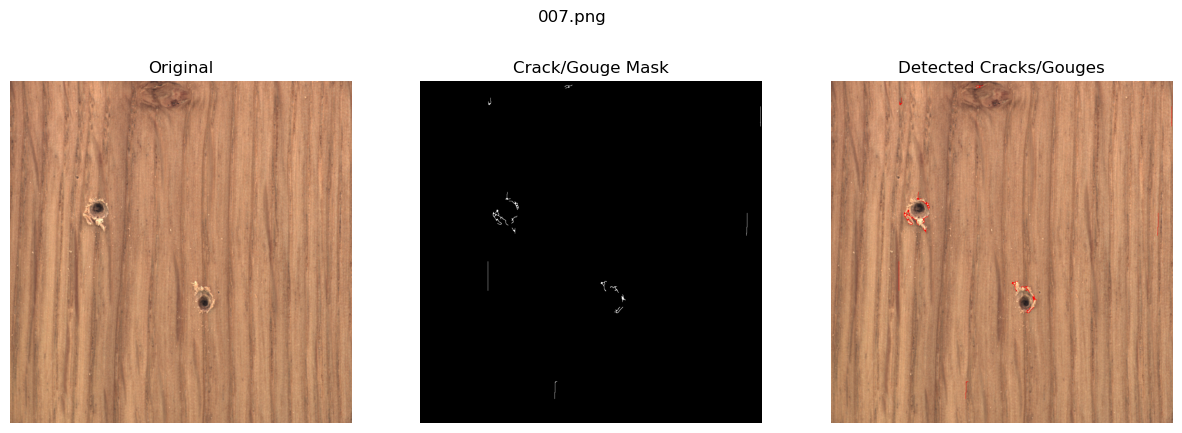

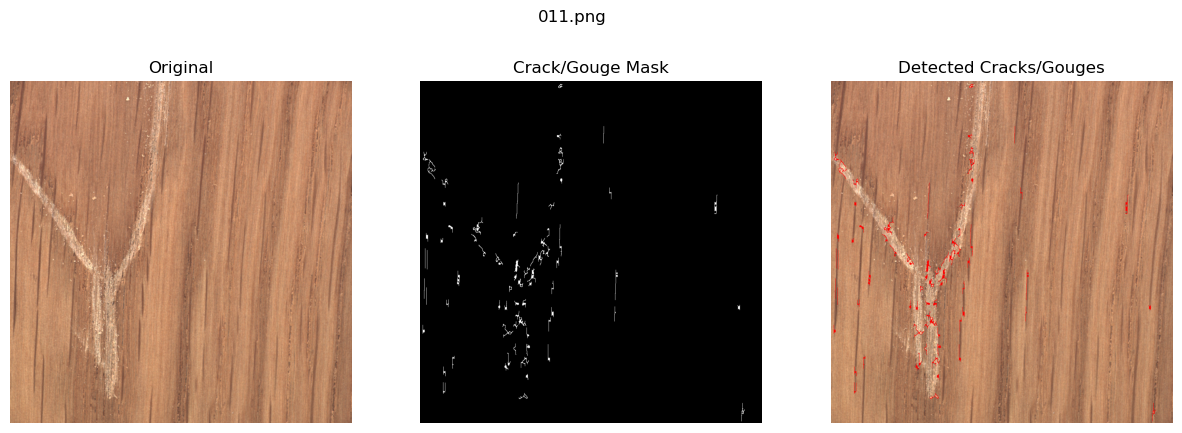

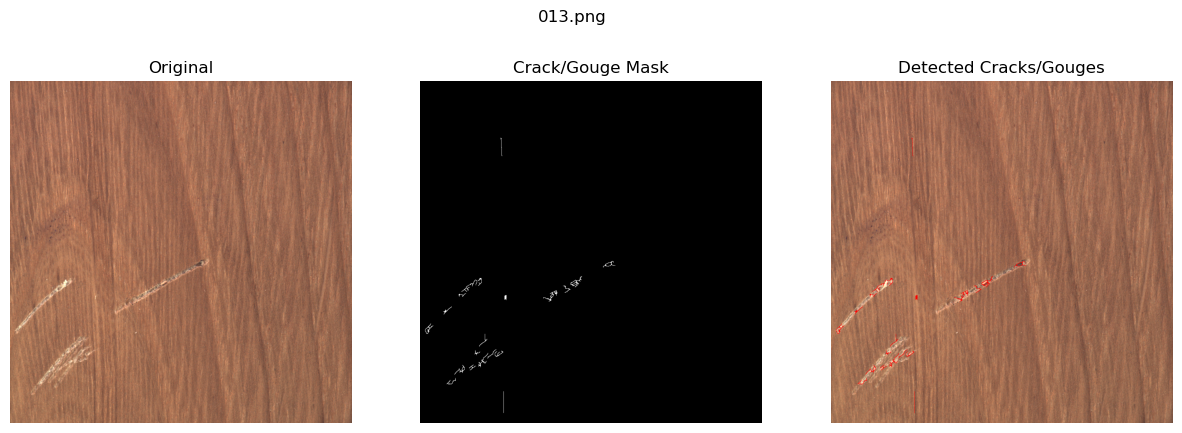

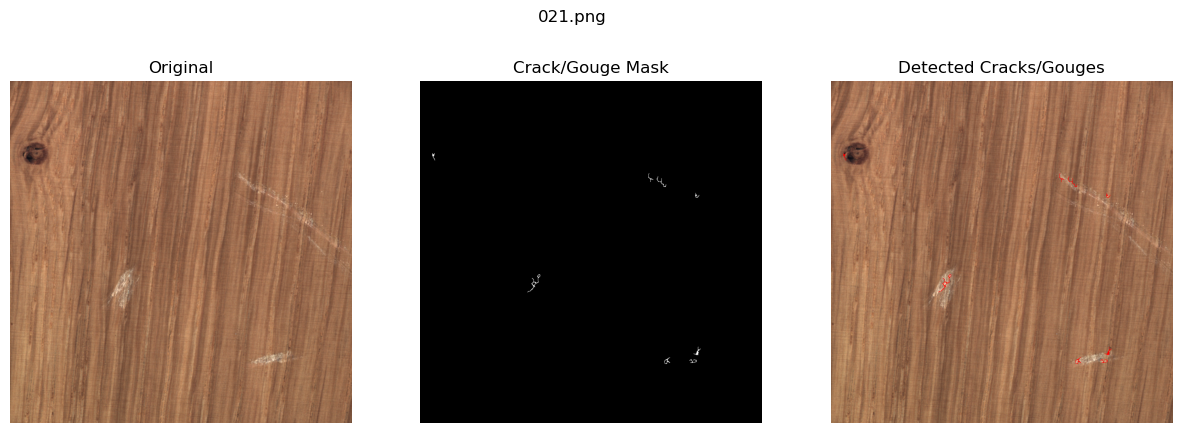

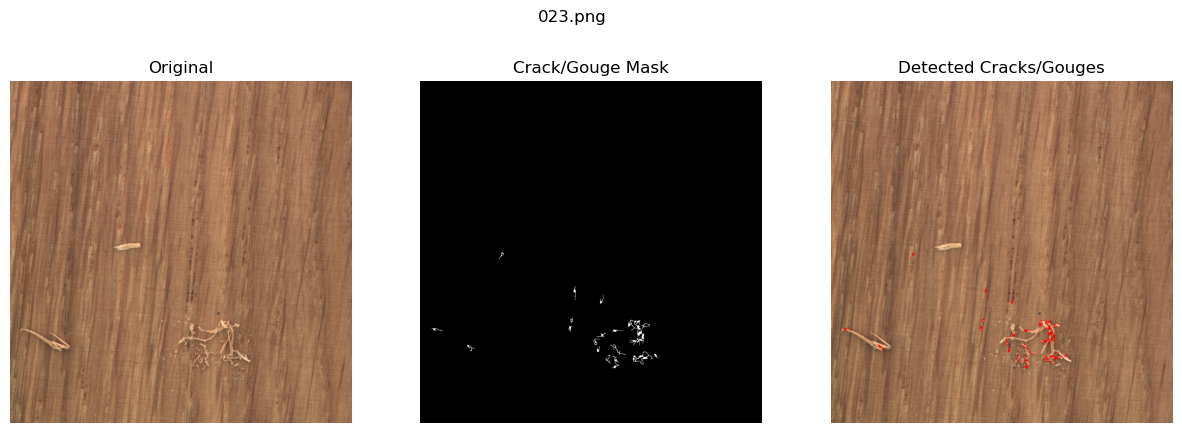

In [15]:
# Selected crack/gouge images from wood folder

image_files = [
    "007.png",
    "011.png",
    "013.png",
    "021.png",
    "023.png"
]


input_folder = "wood"


for filename in image_files:

    image_path = os.path.join(input_folder, filename)

    # Open selected image
    image = Image.open(image_path).convert("RGB")

    image_np = np.array(image)

    # Convert to grayscale
    gray = color.rgb2gray(image_np)

    # Blur image to reduce wood-grain noise using guassian
    blurred = filters.gaussian(
        gray,
        sigma=1
    )

    # Detect crack/gouge edges
    edges = feature.canny(
        blurred,
        sigma=2
    )

    # Connect crack/gouge lines
    closed = morphology.binary_closing(
        edges,
        morphology.disk(2)
    )

    # Remove small noise
    cleaned = morphology.remove_small_objects(
        closed,
        min_size=50
    )

    # Create output overlay
    output = image_np.copy()

    # Color detected regions red
    output[cleaned] = [255, 0, 0]

    # Display results
    plt.figure(figsize=(15,5))

    # Original image
    plt.subplot(1,3,1)
    plt.imshow(image_np)
    plt.title("Original")
    plt.axis("off")

    # Binary mask
    plt.subplot(1,3,2)
    plt.imshow(cleaned, cmap="gray")
    plt.title("Crack/Gouge Mask")
    plt.axis("off")

    # Overlay result
    plt.subplot(1,3,3)
    plt.imshow(output)
    plt.title("Detected Cracks/Gouges")
    plt.axis("off")

    plt.suptitle(filename)

    plt.show()